In [2]:
import numpy as np

data = np.load("training_history.npz")   # デフォルトで読み込みは lazy
print(data.files)               # ['arr_0', 'x', 'y', ...] キー一覧

for k in data.files:
    arr = data[k]
    print(k, arr.shape, arr.dtype)

['train_loss', 'train_acc', 'valid_loss', 'valid_acc']
train_loss (50,) float64
train_acc (50,) float64
valid_loss (50,) float64
valid_acc (50,) float64


In [3]:
# Summary of training history (.npz)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
npz_path = 'training_history.npz'
data = np.load(npz_path)
keys = data.files
print('Keys:', keys)
lengths = {k: len(data[k]) for k in keys}
print('Lengths:', lengths)
epochs = range(1, lengths[keys[0]]+1)
train_loss = data['train_loss']
valid_loss = data['valid_loss']
train_acc = data['train_acc']
valid_acc = data['valid_acc']
best_acc_epoch = int(valid_acc.argmax()) + 1
best_acc = valid_acc.max()
best_loss_epoch = int(valid_loss.argmin()) + 1
best_val_loss = valid_loss.min()
print(f'Best validation accuracy: {best_acc:.4f} at epoch {best_acc_epoch}')
print(f'Lowest validation loss: {best_val_loss:.4f} at epoch {best_loss_epoch}')

Keys: ['train_loss', 'train_acc', 'valid_loss', 'valid_acc']
Lengths: {'train_loss': 50, 'train_acc': 50, 'valid_loss': 50, 'valid_acc': 50}
Best validation accuracy: 0.9834 at epoch 2
Lowest validation loss: 0.0560 at epoch 9


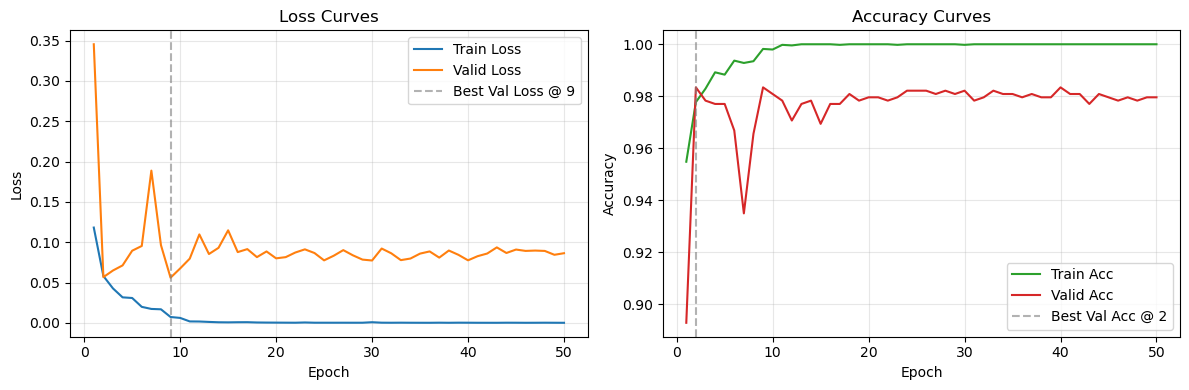

In [4]:
# Plot loss and accuracy curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_loss, label='Train Loss', color='tab:blue')
plt.plot(epochs, valid_loss, label='Valid Loss', color='tab:orange')
plt.axvline(best_loss_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best Val Loss @ {best_loss_epoch}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(epochs, train_acc, label='Train Acc', color='tab:green')
plt.plot(epochs, valid_acc, label='Valid Acc', color='tab:red')
plt.axvline(best_acc_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best Val Acc @ {best_acc_epoch}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Export to DataFrame and save CSV + figure
df = pd.DataFrame({
    'epoch': list(epochs),
    'train_loss': train_loss,
    'valid_loss': valid_loss,
    'train_acc': train_acc,
    'valid_acc': valid_acc,
})
print(df.head())
csv_out = 'training_history_summary.csv'
df.to_csv(csv_out, index=False)
print('Saved CSV ->', csv_out)

# Save static plot
fig_path = 'training_curves.png'
plt.figure(figsize=(10,4))
plt.plot(epochs, valid_acc, label='Valid Acc', color='tab:red')
plt.plot(epochs, train_acc, label='Train Acc', color='tab:green', alpha=0.6)
plt.scatter([best_acc_epoch],[best_acc], color='black', zorder=5, label=f'Best {best_acc:.4f}')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Validation Accuracy'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_path, dpi=150)
plt.close()
print('Saved plot ->', fig_path)

# Optional: compute generalization gap
gap = (train_acc - valid_acc)
print(f'Mean generalization gap: {gap.mean():.4f} (train - valid)')

   epoch  train_loss  valid_loss  train_acc  valid_acc
0      1    0.118136    0.345403   0.954811   0.892857
1      2    0.058048    0.056660   0.977743   0.983418
2      3    0.042665    0.064897   0.982914   0.978316
3      4    0.031603    0.071212   0.989209   0.977041
4      5    0.030800    0.089411   0.988309   0.977041
Saved CSV -> training_history_summary.csv
Saved plot -> training_curves.png
Mean generalization gap: 0.0210 (train - valid)
Saved plot -> training_curves.png
Mean generalization gap: 0.0210 (train - valid)
